# K-NN (KNearst Neighbors) Algorithm

# 0/ Library Imports

In [ ]:
# Numpy
%pip install pandas
import pandas as pd

# Sklearn
%pip install scikit-learn
# Import train_test_split function
from sklearn.model_selection import train_test_split
# Import StandardScaler for KNN
from sklearn.preprocessing import StandardScaler
# Import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import ConfusionMatrixDisplay
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Numpy
%pip install numpy
import numpy as np

# Matplotlib
%pip install matplotlib
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# 1/ Dataset Preparation

## 1.1/ Data Loading


In [73]:
# Import [all_dataset.csv]
df = pd.read_csv('../datasets/all_dataset.csv')

# Show the first 5 rows
df.head()


,timestamp,BLUE.HEXTECH_DRAGON.kills,BLUE.WATER_DRAGON.kills,BLUE.FIRE_DRAGON.kills,BLUE.EARTH_DRAGON.kills,BLUE.AIR_DRAGON.kills,BLUE.CHEMTECH_DRAGON.kills,BLUE.ELDER_DRAGON.kills,BLUE.RIFTHERALD.kills,BLUE.BARON_NASHOR.kills,...,soul_Mountain,soul_Ocean,BLUE.minionRatio,RED.minionRatio,BLUE.totalGoldRatio,RED.totalGoldRatio,BLUE.levelRatio,RED.levelRatio,BLUE.kda,RED.kda
0,0,0,0,0,0,0,0,0,0,0,...,0,0,NaN,NaN,inf,inf,inf,inf,NaN,NaN
1,60020,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.000000,0.041653,0.041653,0.000083,0.000083,NaN,NaN
2,120021,0,0,0,0,0,0,0,0,0,...,0,0,0.000133,0.000092,0.025362,0.024654,0.000050,0.000050,NaN,NaN
3,180053,0,0,0,0,0,0,0,0,0,...,0,0,0.000355,0.000267,0.025293,0.024232,0.000072,0.000072,NaN,NaN
4,240057,0,0,0,0,0,0,0,0,0,...,0,0,0.000404,0.000354,0.024673,0.025323,0.000071,0.000075,0.0,inf


## 1.2/ Handle missing values and infinities & Data Preprocessing

In [74]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# Verify that missing values have been fixed
df.isnull().sum()

timestamp                        0
BLUE.HEXTECH_DRAGON.kills        0
BLUE.WATER_DRAGON.kills          0
BLUE.FIRE_DRAGON.kills           0
BLUE.EARTH_DRAGON.kills          0
BLUE.AIR_DRAGON.kills            0
BLUE.CHEMTECH_DRAGON.kills       0
BLUE.ELDER_DRAGON.kills          0
BLUE.RIFTHERALD.kills            0
BLUE.BARON_NASHOR.kills          0
BLUE.HORDE.kills                 0
BLUE.ATAKHAN.kills               0
RED.HEXTECH_DRAGON.kills         0
RED.WATER_DRAGON.kills           0
RED.FIRE_DRAGON.kills            0
RED.EARTH_DRAGON.kills           0
RED.AIR_DRAGON.kills             0
RED.CHEMTECH_DRAGON.kills        0
RED.ELDER_DRAGON.kills           0
RED.RIFTHERALD.kills             0
RED.BARON_NASHOR.kills           0
RED.HORDE.kills                  0
RED.ATAKHAN.kills                0
BLUE.TOWER_BUILDING.kills        0
RED.TOWER_BUILDING.kills         0
BLUE.INHIBITOR_BUILDING.kills    0
RED.INHIBITOR_BUILDING.kills     0
winner                           0
soul_Chemtech       

In [75]:
# Drop unnecessary columns
df.drop(columns=["timestamp"], inplace=True)

## 1.3/ Target and Features

In [76]:
# Define features and target
X = df.drop(columns=["BLUE.kda"])  # Features
y = df["BLUE.kda"]  # Target

## 1.4/ Train-Test Split

In [77]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print train and test set shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(44674, 40) (11169, 40) (44674,) (11169,)


## 1.5/ Feature Scaling & Normalization

In [78]:
# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2/ K-NN Algorithm

In [79]:
# Initialize the classifier
knn = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

KNeighborsRegressor()

## 3/ Model Evaluation

### 3.1/ Predict using the model

In [80]:
# Predict
y_pred = knn.predict(X_test)

### 3.2/ Model Evaluation

Mean Absolute Error (MAE): 0.5417
Mean Squared Error (MSE): 1.2839
Root Mean Squared Error (RMSE): 1.1331
R^2 Score: 0.7272
Mean Squared Error: 1.28385947471102


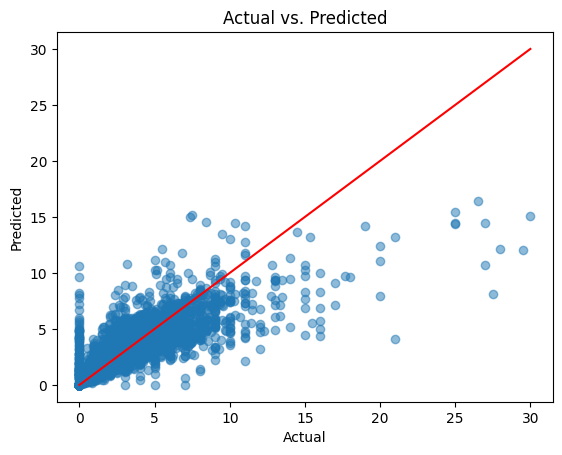

In [81]:
# Show statistics
# Evaluate regression
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")

print(f"Mean Squared Error: {mse}")

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs. Predicted")
plt.show()


## 4/ Fine Tuning the Model

In [ ]:
param_grid = {'n_neighbors': range(1, 30)}
grid = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print("Best k:", grid.best_params_['n_neighbors'])


Best k: 3
